<a href="https://colab.research.google.com/github/kishoreoffl27-ux/python-hw/blob/main/CNNProj.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
import zipfile
import os

In [ ]:
zip_path = "/content/Garbb.zip"
extract_path = "/content/Garbb_dataset"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

##data
dataset_path = extract_path

In [ ]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(128, 128),
    batch_size=32
)

Found 5054 files belonging to 2 classes.
Using 1010 files for validation.


In [ ]:
val_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(128, 128),
    batch_size=32
)

In [ ]:
class_names = train_ds.class_names

print("Classes:")
print(class_names)

Classes:
['Garbage classification', 'garbage classification']


In [ ]:

model = models.Sequential([

    # Normalize pixels: 0-255 → 0-1
    layers.Rescaling(
        1./255,
        input_shape=(128, 128, 3)
    ),

    # First convolution block
    layers.Conv2D(
        32,
        (3, 3),
        activation="relu"
    ),

    layers.MaxPooling2D(),

    # Second convolution block
    layers.Conv2D(
        64,
        (3, 3),
        activation="relu"
    ),

    layers.MaxPooling2D(),

    # Third convolution block
    layers.Conv2D(
        128,
        (3, 3),
        activation="relu"
    ),

    layers.MaxPooling2D(),

    # Convert feature maps to 1D
    layers.Flatten(),

    # Classification layer
    layers.Dense(
        128,
        activation="relu"
    ),

    # Output layer
    layers.Dense(
        len(class_names),
        activation="softmax"
    )
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Epoch 1/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 45s 1s/step - accuracy: 0.5188 - loss: 0.6947 - val_accuracy: 0.5327 - val_loss: 0.6870
Epoch 2/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 83s 1s/step - accuracy: 0.5436 - loss: 0.6870 - val_accuracy: 0.5693 - val_loss: 0.6743
Epoch 3/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 90s 2s/step - accuracy: 0.5634 - loss: 0.6753 - val_accuracy: 0.5703 - val_loss: 0.6640
Epoch 4/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 72s 1s/step - accuracy: 0.5931 - loss: 0.6605 - val_accuracy: 0.6089 - val_loss: 0.6358
Epoch 5/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 52s 2s/step - accuracy: 0.6129 - loss: 0.6573 - val_accuracy: 0.6475 - val_loss: 0.6105
Epoch 6/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 53s 2s/step - accuracy: 0.6218 - loss: 0.6241 - val_accuracy: 0.6762 - val_loss: 0.5849
Epoch 7/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 73s 1s/step - accuracy: 0.6416 - loss: 0.6022 - val_accuracy: 0.6980 - val_loss: 0.5381
Epoch 8/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 42s 1s/step - accuracy: 0.6733 - loss: 0.5722 - val_accuracy: 0.7149 - val_loss:

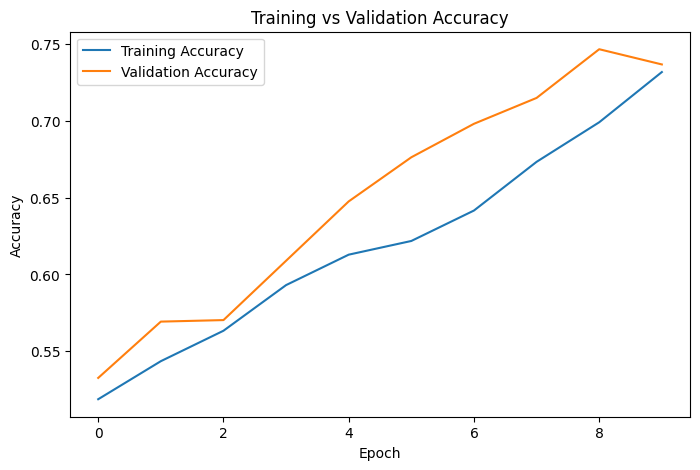

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()

plt.show()

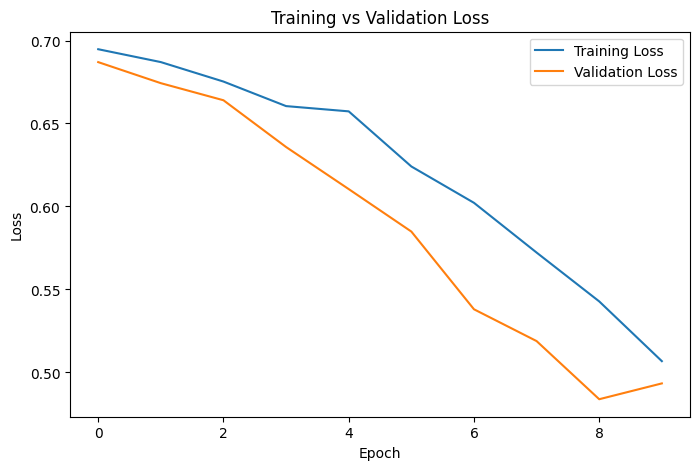

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()

plt.show()

In [ ]:
loss, accuracy = model.evaluate(val_ds)

print("\n==========================")
print("MODEL PERFORMANCE")
print("==========================")

print(f"Validation Accuracy: {accuracy * 100:.2f}%")
print(f"Validation Loss: {loss:.4f}")

32/32 ━━━━━━━━━━━━━━━━━━━━ 11s 328ms/step - accuracy: 0.7366 - loss: 0.4934

MODEL PERFORMANCE
Validation Accuracy: 73.66%
Validation Loss: 0.4934


In [ ]:
image_path = "/content/test.jpg"

img = tf.keras.utils.load_img(
    image_path,
    target_size=(128, 128)
)

img_array = tf.keras.utils.img_to_array(img)

img_array = tf.expand_dims(
    img_array,
    0
)

predictions = model.predict(img_array)

predicted_index = np.argmax(
    predictions[0]
)

predicted_class = class_names[
    predicted_index
]

confidence = (
    np.max(predictions[0]) * 100
)

FileNotFoundError: [Errno 2] No such file or directory: '/content/test.jpg'

In [ ]:
plt.imshow(img)
plt.axis("off")

plt.title(
    f"Prediction: {predicted_class}\n"
    f"Confidence: {confidence:.2f}%"
)

plt.show()

print("\n==========================")
print("PREDICTION")
print("==========================")

print(f"Class: {predicted_class}")
print(f"Confidence: {confidence:.2f}%")